Training on 14600 fights, Testing on 3650 fights...
[0]	validation_0-logloss:0.69189	validation_1-logloss:0.69290
[100]	validation_0-logloss:0.62577	validation_1-logloss:0.67312
[200]	validation_0-logloss:0.60653	validation_1-logloss:0.66352
[300]	validation_0-logloss:0.59529	validation_1-logloss:0.65960
[400]	validation_0-logloss:0.58714	validation_1-logloss:0.65775
[465]	validation_0-logloss:0.58250	validation_1-logloss:0.65764

--- Results ---
Accuracy: 0.6074
ROC AUC:  0.6578

Confusion Matrix:
[[1102  723]
 [ 710 1115]]


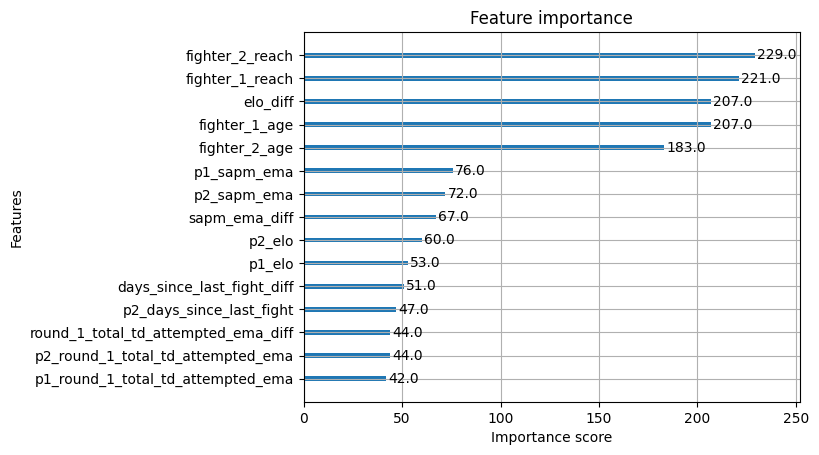

In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# 1. Load Data
# Assuming the data is in a file named 'ufc_data.csv'
df = pd.read_csv('train.csv')

# 2. Preprocessing
# Convert date to datetime
df['event_date'] = pd.to_datetime(df['event_date'])

# Sort by date (CRITICAL for sports betting models)
df = df.sort_values(by='event_date')

# Drop rows where target is missing (if any)
df = df.dropna(subset=['meta_first_fighter_won'])

# Select Features
# We drop non-predictive metadata (names, dates) and the target variable
target = 'meta_first_fighter_won'
meta_cols = ['event_date', 'fighter_1', 'fighter_2', target]
features = [col for col in df.columns if col not in meta_cols]

# 3. Time-Series Split
# Train on first 80% of chronological fights, test on most recent 20%
split_idx = int(len(df) * 0.8)

X = df[features]
y = df[target]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. The "Best" Robust Baseline Parameters
# These are tuned for high-noise tabular data (like sports) to prevent overfitting
params = {
    'objective': 'binary:logistic',
    'n_estimators': 2000,         
    'learning_rate': 0.02,        # Lowered: Learn slower to find the "global" minimum
    'max_depth': 3,               # Lowered: Depth 3 prevents complex, noisy interactions
    'min_child_weight': 5,        # New: Requires more data samples to create a leaf node
    'gamma': 0.2,                 # Increased: Harder to make a split
    'subsample': 0.7,             # Lowered: More randomness to prevent memorization
    'colsample_bytree': 0.7,      
    'reg_lambda': 5.0,            # Increased: Stronger L2 regularization
    'scale_pos_weight': 1,
    'random_state': 42,
    'tree_method': 'hist'
}

# 5. Training with Early Stopping
model = xgb.XGBClassifier(**params, early_stopping_rounds=50)

print(f"Training on {len(X_train)} fights, Testing on {len(X_test)} fights...")

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100  # Print progress every 100 rounds
)

# 6. Evaluation
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

print(f"\n--- Results ---")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

# 7. Feature Importance (Check what actually matters)
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=15)
plt.show()